# Unit 6 — Fine-Tuning a Pretrained LLM

**Task Identification:** Multi-class text classification

**Domain:** Agricultural advisory (pest, disease, soil, irrigation)

**Pretrained LLM:** `distilbert-base-uncased`

---

### Steps Followed
1. Identified the task → sequence classification (4 categories)
2. Identified the domain → Philippine / general agricultural advisory text
3. Identified the LLM → DistilBERT (distilbert-base-uncased, ~66M params)
4. Established fine-tuning configuration → HuggingFace Trainer API
5. Performed evaluation → Accuracy + Weighted F1, plus PCA embedding visualization

`Imports`

In [1]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
import evaluate
from sklearn.decomposition import PCA

print("All libraries imported successfully!")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version : 2.11.0+cpu
CUDA available  : False


`Dataset (Agricultural Domain)`

In [2]:
# Agricultural advisory text
# 4-class sequence classification
#   0 = pest | 1 = disease | 2 = soil | 3 = irrigation

id2label = {0: "pest", 1: "disease", 2: "soil", 3: "irrigation"}
label2id = {v: k for k, v in id2label.items()}

examples = [
    # pest (label 0)
    {"text": "Rice field scouting found stem borer damage in tillering stage with dead hearts in scattered patches.", "label": 0},
    {"text": "Maize leaves show chewing injury and frass near the whorl, suggesting fall armyworm infestation.", "label": 0},
    {"text": "Aphids were clustered on the underside of eggplant leaves, causing curling and sticky honeydew deposits.", "label": 0},
    {"text": "Brown planthopper populations increased after continuous flooding and dense rice planting.", "label": 0},
    {"text": "Farm technicians observed leaf folder larvae folding rice leaves and feeding inside the folded blade.", "label": 0},
    {"text": "Tomato fruits had puncture marks and larvae inside, indicating fruit borer attack.", "label": 0},
    {"text": "The farmer reported whiteflies spreading quickly in the okra plot during hot dry weather.", "label": 0},
    {"text": "Cutworms were severing newly transplanted cabbage seedlings at the base during the night.", "label": 0},
    {"text": "Thrips damage caused silvery streaks on onion leaves and reduced vigor in young plants.", "label": 0},
    {"text": "Weevils bored into stored corn grain, leaving powdery residues and exit holes.", "label": 0},
    {"text": "Leaf miners created winding tunnels across the leaf surface of the bean crop.", "label": 0},
    {"text": "Spider mites caused bronzing and fine webbing on drought-stressed peanut plants.", "label": 0},
    # disease (label 1)
    {"text": "Rice leaves developed spindle-shaped lesions with gray centers, a classic symptom of blast disease.", "label": 1},
    {"text": "Tomato plants showed yellowing, wilting, and dark vascular tissue consistent with bacterial wilt.", "label": 1},
    {"text": "Banana leaves displayed yellow streaks and necrotic patches associated with sigatoka infection.", "label": 1},
    {"text": "Powdery white fungal growth covered cucumber leaves during humid mornings.", "label": 1},
    {"text": "Corn plants had elongated gray leaf spots that expanded rapidly after repeated rain.", "label": 1},
    {"text": "Cassava stems and leaves exhibited mosaic patterns and distorted growth.", "label": 1},
    {"text": "Pepper seedlings collapsed at the base due to damping-off in the nursery tray.", "label": 1},
    {"text": "Soybean foliage showed rust pustules on the lower leaf surface and premature defoliation.", "label": 1},
    {"text": "Citrus trees had canker-like raised lesions with yellow halos on leaves and fruit.", "label": 1},
    {"text": "Papaya fruits developed water-soaked lesions that turned soft and sunken after harvest.", "label": 1},
    {"text": "The potato plot showed late blight symptoms with dark lesions and white growth under moist conditions.", "label": 1},
    {"text": "Peanut leaves presented circular brown spots that merged and caused heavy leaf drop.", "label": 1},
    # soil (label 2)
    {"text": "Soil test results showed low nitrogen, low organic matter, and strongly acidic pH in the topsoil.", "label": 2},
    {"text": "The field has compacted clay soil with poor drainage and restricted root penetration.", "label": 2},
    {"text": "Laboratory analysis reported phosphorus deficiency and moderate potassium availability.", "label": 2},
    {"text": "Salinity levels were elevated in the irrigated plot, causing poor seedling establishment.", "label": 2},
    {"text": "The farm adviser recommended lime application because soil pH was below 5.0.", "label": 2},
    {"text": "Soil texture in the vegetable bed was sandy loam with low water-holding capacity.", "label": 2},
    {"text": "Nutrient mapping revealed zinc deficiency in several sections of the rice farm.", "label": 2},
    {"text": "Root development was limited by a hardpan layer detected beneath the plow depth.", "label": 2},
    {"text": "The compost-amended plot had higher organic carbon and better crumb structure.", "label": 2},
    {"text": "Excessive soil acidity may be reducing nutrient uptake in the corn field.", "label": 2},
    {"text": "The extension report noted boron deficiency symptoms linked to poor soil micronutrient balance.", "label": 2},
    {"text": "Waterlogging persisted because the soil profile had slow infiltration and weak internal drainage.", "label": 2},
    # irrigation (label 3)
    {"text": "Alternate wetting and drying was recommended for rice to reduce water use without lowering yield.", "label": 3},
    {"text": "The irrigation schedule should be shifted to early morning to reduce evaporation losses.", "label": 3},
    {"text": "Drip irrigation lines were installed to improve water efficiency in the tomato field.", "label": 3},
    {"text": "Canal delivery was delayed, so the farmer adjusted transplanting to match water availability.", "label": 3},
    {"text": "Moisture sensors indicated the root zone was still wet, so irrigation was postponed.", "label": 3},
    {"text": "Furrow irrigation caused uneven water distribution across the sloping field.", "label": 3},
    {"text": "The advisory suggested shorter but more frequent irrigation during flowering stage.", "label": 3},
    {"text": "Pump discharge was insufficient to meet peak water demand in the dry season.", "label": 3},
    {"text": "Mulching was combined with drip irrigation to conserve moisture in the vegetable plot.", "label": 3},
    {"text": "Over-irrigation increased standing water and may have worsened root stress.", "label": 3},
    {"text": "The reservoir level dropped sharply, requiring stricter irrigation rotation among farmers.", "label": 3},
    {"text": "Sprinkler coverage was inconsistent because of low pressure and clogged nozzles.", "label": 3},
]

random.seed(42)
random.shuffle(examples)

split_idx   = int(len(examples) * 0.8)
train_data  = examples[:split_idx]
valid_data  = examples[split_idx:]

train_dataset = Dataset.from_list(train_data)
valid_dataset = Dataset.from_list(valid_data)

print(f"Total examples  : {len(examples)}")
print(f"Training samples: {len(train_data)}")
print(f"Validation set  : {len(valid_data)}")
print(f"Classes         : {list(id2label.values())}")

Total examples  : 48
Training samples: 38
Validation set  : 10
Classes         : ['pest', 'disease', 'soil', 'irrigation']


`Load Pretrained LLM & Tokenizer`

In [3]:
# LLM: distilbert-base-uncased
# Architecture : 6 transformer layers, 12 heads, hidden=768, ~66M params

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
valid_dataset = valid_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
)

print(f"Model loaded    : {MODEL_NAME}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Map:   0%|          | 0/38 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded    : distilbert-base-uncased
Total parameters: 66,956,548


`Fine-Tuning Configuration & Training`

In [4]:
# Fine-tuning configuration

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"    : accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_weighted" : f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

training_args = TrainingArguments(
    output_dir                = "./agri-distilbert-output",
    learning_rate             = 2e-5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    num_train_epochs          = 6,
    weight_decay              = 0.01,
    eval_strategy             = "epoch",
    save_strategy             = "epoch",
    load_best_model_at_end    = True,
    logging_steps             = 5,
    report_to                 = "none",
)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_dataset,
    eval_dataset      = valid_dataset,
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete.")

Starting fine-tuning...


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.377895,1.412954,0.400000,0.258333
2,1.317110,1.390178,0.500000,0.346667
3,1.218101,1.348160,0.500000,0.346667
4,1.163632,1.310197,0.500000,0.346667
5,1.115332,1.284058,0.500000,0.346667
6,1.083179,1.271740,0.500000,0.346667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Fine-tuning complete.


`Evaluation (Accuracy + Weighted F1)`

In [5]:
# Evaluation

# Initialize trainer state if train() was not called in this session
trainer.control = trainer.callback_handler.on_train_begin(
    trainer.args, trainer.state, trainer.control
)

metrics = trainer.evaluate()

print("\n=== Evaluation Results ===")
print(f"  Accuracy     : {metrics['eval_accuracy']:.4f}")
print(f"  F1 (weighted): {metrics['eval_f1_weighted']:.4f}")
print(f"  Eval Loss    : {metrics['eval_loss']:.4f}")

trainer.save_model("./agri-distilbert-final")
tokenizer.save_pretrained("./agri-distilbert-final")
print("\nModel saved → ./agri-distilbert-final")

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
6,1.083179,1.271740,0.500000,0.346667



=== Evaluation Results ===
  Accuracy     : 0.5000
  F1 (weighted): 0.3467
  Eval Loss    : 1.2717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved → ./agri-distilbert-final


`Inference Demo`

In [6]:
sample_docs = [
    "Rice leaves have diamond-shaped lesions and the disease is spreading after rain.",
    "Soil analysis shows low nitrogen and acidic pH across the field.",
    "Drip lines reduced water loss and improved irrigation efficiency in tomato rows.",
    "Aphids and whiteflies were found on the underside of tomato leaves.",
]

inputs = tokenizer(sample_docs, truncation=True, padding=True, return_tensors="pt")
model.eval()
with torch.no_grad():
    outputs = model(**inputs)

preds = outputs.logits.argmax(dim=-1).tolist()

print("=== Inference Results ===")
for text, pred in zip(sample_docs, preds):
    print(f"\nTEXT  : {text}")
    print(f"LABEL : {id2label[pred].upper()}")

=== Inference Results ===

TEXT  : Rice leaves have diamond-shaped lesions and the disease is spreading after rain.
LABEL : DISEASE

TEXT  : Soil analysis shows low nitrogen and acidic pH across the field.
LABEL : SOIL

TEXT  : Drip lines reduced water loss and improved irrigation efficiency in tomato rows.
LABEL : IRRIGATION

TEXT  : Aphids and whiteflies were found on the underside of tomato leaves.
LABEL : DISEASE


`PCA Visualization of Fine-Tuned Embeddings`

Extracted the **[CLS] token embedding** from the fine-tuned DistilBERT for each of 24 agricultural keywords, then reduce to 2D with PCA and visualize by semantic category.

Embedding matrix shape: (24, 768)   (24 words × 768 dims)
Variance explained → PC1: 30.6%   PC2: 10.6%


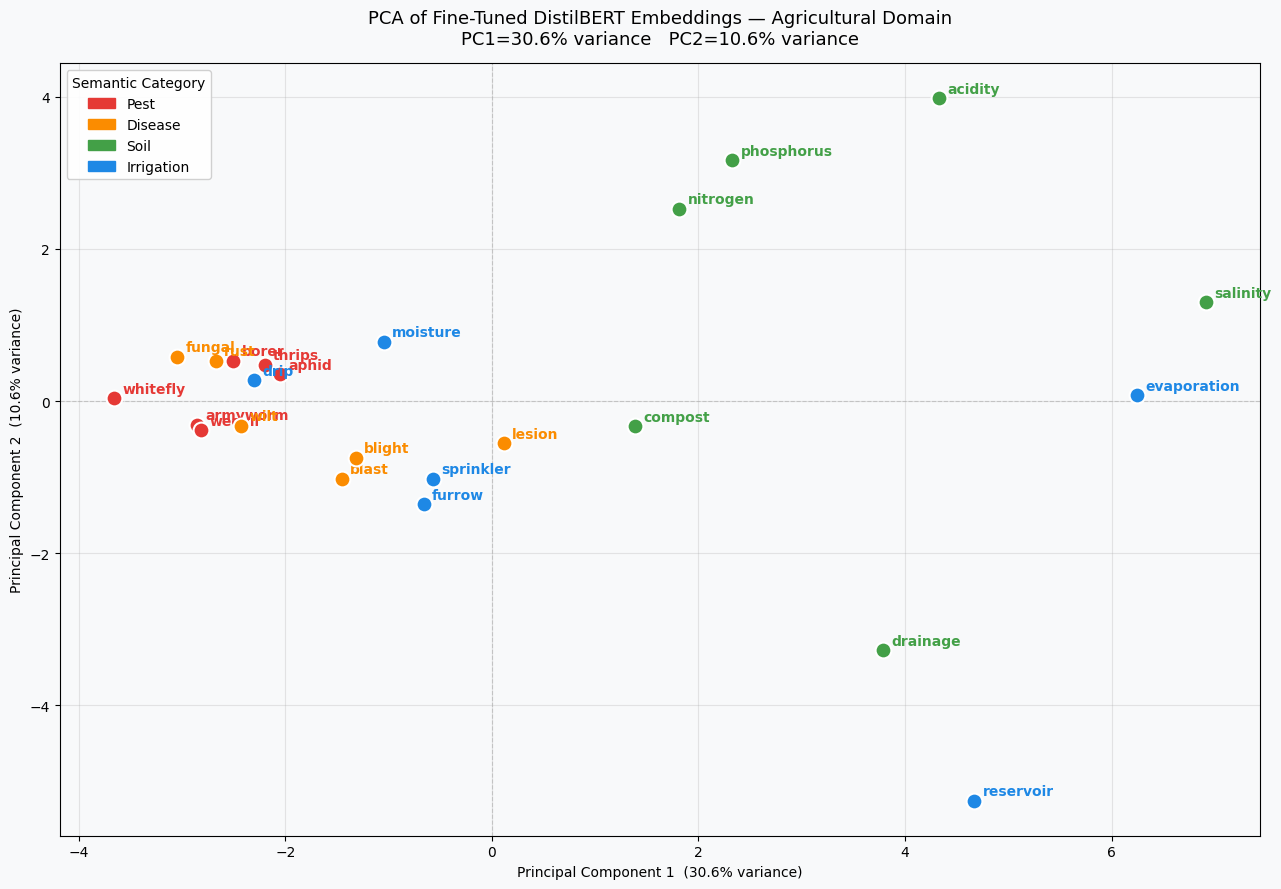

Saved → pca_agri_distilbert.png
Words visualized: 24


In [7]:
# 24 domain keywords (≥ 20 required) grouped by semantic category 
pca_words = {
    "Pest": [
        "aphid", "armyworm", "weevil", "thrips", "whitefly", "borer"
    ],
    "Disease": [
        "blast", "blight", "rust", "wilt", "lesion", "fungal"
    ],
    "Soil": [
        "nitrogen", "phosphorus", "acidity", "compost", "salinity", "drainage"
    ],
    "Irrigation": [
        "drip", "sprinkler", "furrow", "moisture", "reservoir", "evaporation"
    ],
}

category_colors = {
    "Pest"       : "#E53935",   # red
    "Disease"    : "#FB8C00",   # orange
    "Soil"       : "#43A047",   # green
    "Irrigation" : "#1E88E5",   # blue
}

# Extract CLS embeddings
all_words  = []
all_labels = []

for category, words in pca_words.items():
    for word in words:
        all_words.append(word)
        all_labels.append(category)

model.eval()
embeddings = []

with torch.no_grad():
    for word in all_words:
        enc = tokenizer(word, return_tensors="pt")
        # Use the base transformer to get hidden states, not the classifier head
        hidden = model.distilbert(**enc).last_hidden_state   # (1, seq, 768)
        cls_vec = hidden[0, 0, :].numpy()                   # CLS token
        embeddings.append(cls_vec)

vectors = np.array(embeddings)
print(f"Embedding matrix shape: {vectors.shape}   ({len(all_words)} words × 768 dims)")

# PCA → 2D
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)
var    = pca.explained_variance_ratio_
print(f"Variance explained → PC1: {var[0]:.1%}   PC2: {var[1]:.1%}")

# Plot 
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for i, (word, cat) in enumerate(zip(all_words, all_labels)):
    x, y  = coords[i]
    color = category_colors[cat]
    ax.scatter(x, y, color=color, s=130, zorder=3,
               edgecolors="white", linewidths=1.5)
    ax.annotate(word, xy=(x, y), xytext=(6, 4),
                textcoords="offset points",
                fontsize=10, color=color, fontweight="bold")

ax.axhline(0, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=1)

legend_handles = [
    mpatches.Patch(color=color, label=cat)
    for cat, color in category_colors.items()
]
ax.legend(handles=legend_handles, loc="upper left",
          framealpha=0.9, fontsize=10, title="Semantic Category")

ax.set_title(
    f"PCA of Fine-Tuned DistilBERT Embeddings — Agricultural Domain\n"
    f"PC1={var[0]:.1%} variance   PC2={var[1]:.1%} variance",
    fontsize=13, pad=14
)
ax.set_xlabel(f"Principal Component 1  ({var[0]:.1%} variance)", fontsize=10)
ax.set_ylabel(f"Principal Component 2  ({var[1]:.1%} variance)", fontsize=10)
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("pca_agri_distilbert.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → pca_agri_distilbert.png")
print(f"Words visualized: {len(all_words)}")